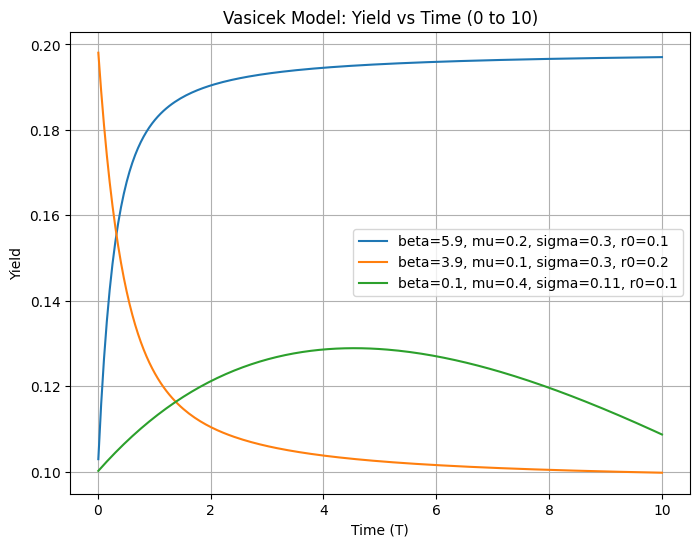

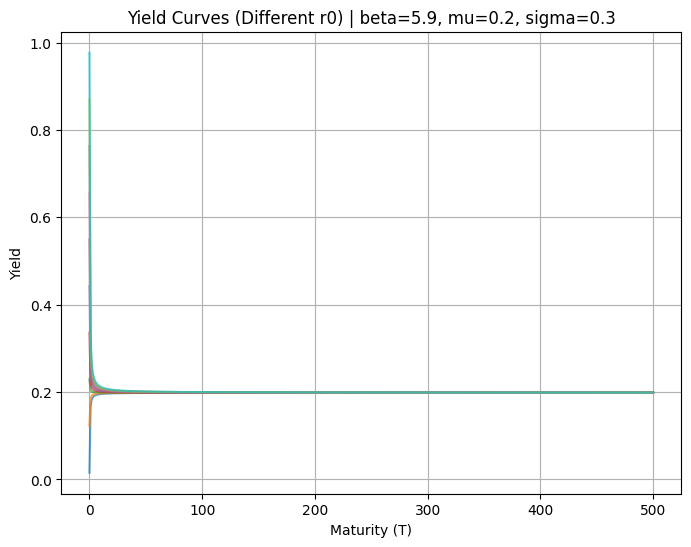

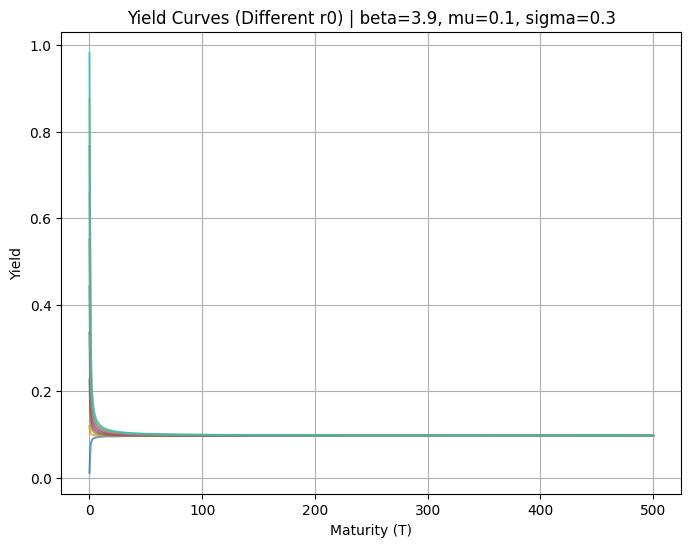

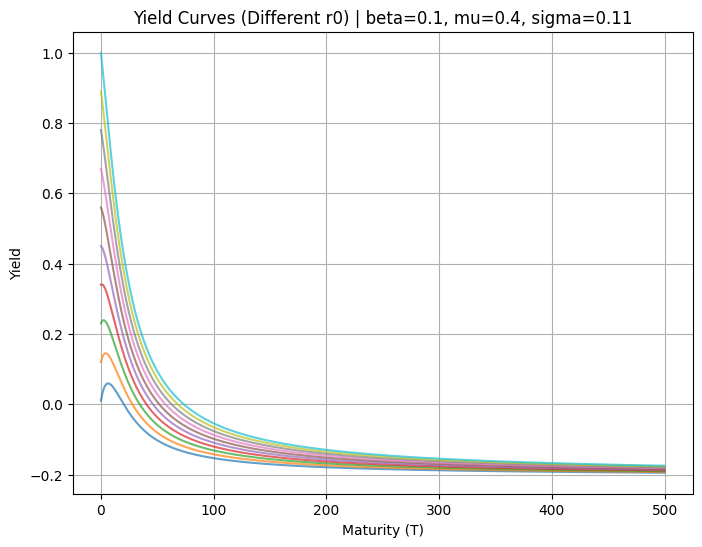

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def B(beta, T):
    return (1 - np.exp(-beta * T)) / beta

def A(beta, mu, sigma, T):
    B_T = B(beta, T)
    term1 = (mu - (sigma**2) / (2 * beta**2)) * (B_T - T)
    term2 = (sigma**2 / (4 * beta)) * (B_T**2)
    return np.exp(term1 - term2)

def bond_price(beta, mu, sigma, r0, T):
    return A(beta, mu, sigma, T) * np.exp(-B(beta, T) * r0)

def yield_curve(beta, mu, sigma, r0, T):
    P = bond_price(beta, mu, sigma, r0, T)
    return -np.log(P) / T

params_list = [
    [5.9, 0.2, 0.3, 0.1],
    [3.9, 0.1, 0.3, 0.2],
    [0.1, 0.4, 0.11, 0.1]
]

T1 = np.linspace(0.01, 10, 200)

plt.figure(figsize=(8,6))

for beta, mu, sigma, r0 in params_list:
    y = yield_curve(beta, mu, sigma, r0, T1)
    plt.plot(T1, y, label=f'beta={beta}, mu={mu}, sigma={sigma}, r0={r0}')

plt.title("Vasicek Model: Yield vs Time (0 to 10)")
plt.xlabel("Time (T)")
plt.ylabel("Yield")
plt.legend()
plt.grid()
plt.show()


T2 = np.linspace(0.01, 500, 500)

for idx, (beta, mu, sigma, _) in enumerate(params_list):

    plt.figure(figsize=(8,6))

    r0_values = np.linspace(0.01, 1, 10)

    for r0 in r0_values:
        y = yield_curve(beta, mu, sigma, r0, T2)
        plt.plot(T2, y, alpha=0.7)

    plt.title(f"Yield Curves (Different r0) | beta={beta}, mu={mu}, sigma={sigma}")
    plt.xlabel("Maturity (T)")
    plt.ylabel("Yield")
    plt.grid()
    plt.show()

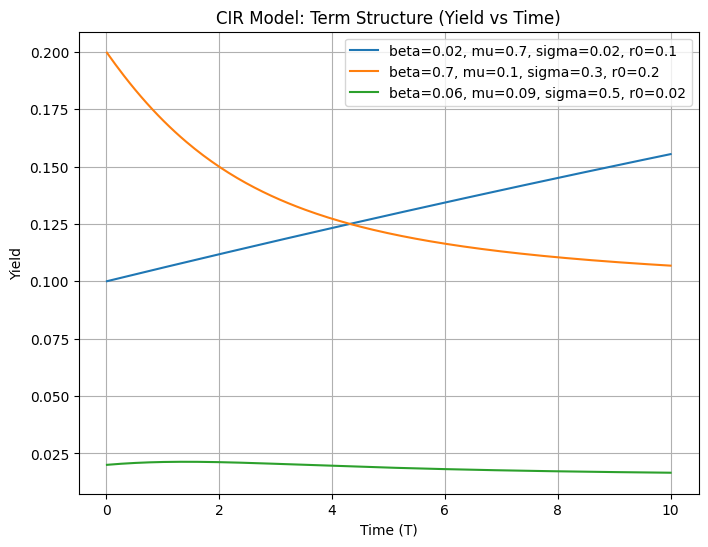

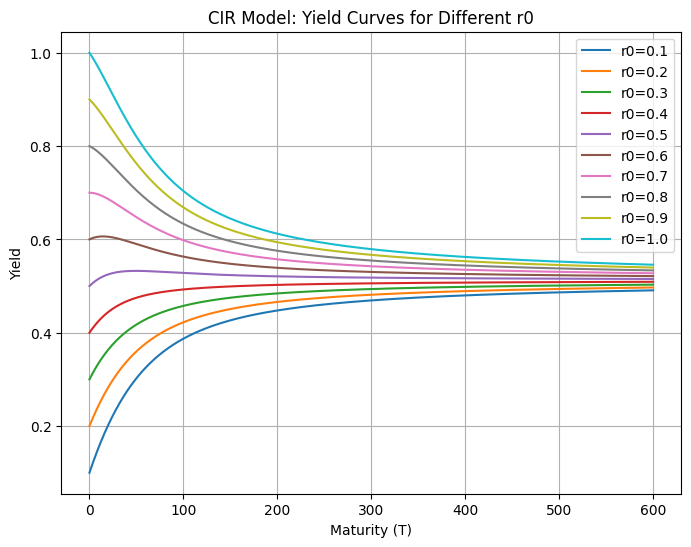

In [2]:
import numpy as np
import matplotlib.pyplot as plt


def gamma(beta, sigma):
    return np.sqrt(beta**2 + 2 * sigma**2)

def B(beta, sigma, T):
    g = gamma(beta, sigma)
    numerator = 2 * (np.exp(g * T) - 1)
    denominator = (g + beta) * (np.exp(g * T) - 1) + 2 * g
    return numerator / denominator

def A(beta, mu, sigma, T):
    g = gamma(beta, sigma)
    numerator = 2 * g * np.exp((beta + g) * T / 2)
    denominator = (g + beta) * (np.exp(g * T) - 1) + 2 * g
    power = (2 * beta * mu) / (sigma**2)
    return (numerator / denominator) ** power

def bond_price(beta, mu, sigma, r0, T):
    return A(beta, mu, sigma, T) * np.exp(-B(beta, sigma, T) * r0)

def yield_curve(beta, mu, sigma, r0, T):
    P = bond_price(beta, mu, sigma, r0, T)
    return -np.log(P) / T


params_list = [
    [0.02, 0.7, 0.02, 0.1],
    [0.7, 0.1, 0.3, 0.2],
    [0.06, 0.09, 0.5, 0.02]
]

T1 = np.linspace(0.01, 10, 200)

plt.figure(figsize=(8,6))

for beta, mu, sigma, r0 in params_list:
    y = yield_curve(beta, mu, sigma, r0, T1)
    plt.plot(T1, y, label=f'beta={beta}, mu={mu}, sigma={sigma}, r0={r0}')

plt.title("CIR Model: Term Structure (Yield vs Time)")
plt.xlabel("Time (T)")
plt.ylabel("Yield")
plt.legend()
plt.grid()
plt.show()


# -------------------------------
# Q2 - Part 2
# Fixed parameters, varying r0
# -------------------------------

beta, mu, sigma = 0.02, 0.7, 0.02

T2 = np.linspace(0.01, 600, 600)

r0_values = np.arange(0.1, 1.1, 0.1)

plt.figure(figsize=(8,6))

for r0 in r0_values:
    y = yield_curve(beta, mu, sigma, r0, T2)
    plt.plot(T2, y, label=f"r0={round(r0,1)}")

plt.title("CIR Model: Yield Curves for Different r0")
plt.xlabel("Maturity (T)")
plt.ylabel("Yield")
plt.legend()
plt.grid()
plt.show()